# Análisis del Agente Connect-4: ADP con Aproximación Lineal (TD-0)


In [1]:
import zipfile, os, sys

with zipfile.ZipFile("tournament.zip", "r") as z:
    z.extractall(".")

sys.path.insert(0, "./tournament")

from connect4.policy import Policy


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from connect4.connect_state import ConnectState

ROWS = 6
COLS = 7

def extract_features(board, player):
    opp = -player
    f = np.zeros(10, dtype=float)
    f[0] = 1.0

    def score_window(w):
        p = int(np.sum(w == player))
        o = int(np.sum(w == opp))
        if p > 0 and o > 0: return
        if p == 1 and o == 0:   f[1] += 1
        elif p == 2 and o == 0: f[2] += 1
        elif p == 3 and o == 0: f[3] += 1
        elif p == 4:             f[4] += 1
        if o == 1 and p == 0:   f[5] += 1
        elif o == 2 and p == 0: f[6] += 1
        elif o == 3 and p == 0: f[7] += 1
        elif o == 4:             f[8] += 1

    for r in range(ROWS):
        for c in range(COLS - 3):
            score_window(board[r, c:c+4])
    for c in range(COLS):
        for r in range(ROWS - 3):
            score_window(board[r:r+4, c])
    for r in range(ROWS - 3):
        for c in range(COLS - 3):
            score_window(np.array([board[r+i, c+i] for i in range(4)]))
    for r in range(3, ROWS):
        for c in range(COLS - 3):
            score_window(np.array([board[r-i, c+i] for i in range(4)]))
    f[9] = np.sum(board[:, COLS // 2] == player)
    return f

def approx_value(board, player, theta):
    return float(theta @ extract_features(board, player))

def drop_piece(board, col, player):
    nb = board.copy()
    for r in reversed(range(ROWS)):
        if nb[r, col] == 0:
            nb[r, col] = player
            return nb
    raise ValueError(f"Column {col} is full")

def check_win_adp(board, player):
    for r in range(ROWS):
        for c in range(COLS - 3):
            if all(board[r, c+i] == player for i in range(4)): return True
    for c in range(COLS):
        for r in range(ROWS - 3):
            if all(board[r+i, c] == player for i in range(4)): return True
    for r in range(ROWS - 3):
        for c in range(COLS - 3):
            if all(board[r+i, c+i] == player for i in range(4)): return True
    for r in range(3, ROWS):
        for c in range(COLS - 3):
            if all(board[r-i, c+i] == player for i in range(4)): return True
    return False

def legal_moves(board):
    return [c for c in range(COLS) if board[0, c] == 0]

def train_adp(n_episodes=2000, alpha_start=0.01, alpha_min=0.001,
              alpha_decay=0.9997, gamma=0.95, epsilon_start=0.15,
              epsilon_min=0.01, epsilon_decay=0.9995, seed=42):
    rng   = np.random.default_rng(seed)
    theta = np.zeros(10)
    R_WIN, R_LOSE, R_DRAW = 1.0, -1.0, 0.0
    for episode in range(n_episodes):
        epsilon = max(epsilon_min, epsilon_start * (epsilon_decay ** episode))
        alpha   = max(alpha_min,   alpha_start   * (alpha_decay   ** episode))
        state   = ConnectState()
        agent_player = -1 if episode % 2 == 0 else 1
        opp_player   = -agent_player
        while not state.is_final():
            if state.player != agent_player:
                state = state.transition(int(rng.choice(state.get_free_cols())))
                continue
            board  = state.board.copy()
            phi_s  = extract_features(board, agent_player)
            v_s    = float(theta @ phi_s)
            legal  = state.get_free_cols()
            if rng.random() < epsilon:
                col = int(rng.choice(legal))
            else:
                best_col, best_val = legal[0], -np.inf
                for c in legal:
                    ns = state.transition(c)
                    if ns.get_winner() == agent_player:
                        best_col = c; break
                    val = approx_value(ns.board, agent_player, theta)
                    if val > best_val:
                        best_val = val; best_col = c
                col = best_col
            next_state = state.transition(col)
            winner = next_state.get_winner()
            if   winner == agent_player: r = R_WIN
            elif winner == opp_player:   r = R_LOSE
            elif next_state.is_final():  r = R_DRAW
            else:                        r = 0.0
            v_next = 0.0 if next_state.is_final() else approx_value(next_state.board, agent_player, theta)
            theta += alpha * (r + gamma * v_next - v_s) * phi_s
            state  = next_state
    return theta

class MyPolicy(Policy):
    def __init__(self, theta=None):
        self.theta = theta if theta is not None else np.zeros(10)
    def mount(self, **kw): pass
    def act(self, s):
        red_count = int(np.sum(s == -1)); yellow_count = int(np.sum(s == 1))
        player = -1 if red_count == yellow_count else 1; opp = -player
        legal  = legal_moves(s)
        if not legal: raise RuntimeError("No legal columns")
        for col in legal:
            if check_win_adp(drop_piece(s, col, player), player): return col
        for col in legal:
            if check_win_adp(drop_piece(s, col, opp), opp): return col
        safe = [c for c in legal if not any(
            check_win_adp(drop_piece(drop_piece(s, c, player), oc, opp), opp)
            for oc in legal_moves(drop_piece(s, c, player)))]
        candidates = safe if safe else legal
        center = COLS // 2
        best_col, best_val = candidates[0], -np.inf
        for col in sorted(candidates, key=lambda c: abs(c - center)):
            val = approx_value(drop_piece(s, col, player), player, self.theta) + (3 - abs(col - center)) * 0.25
            if val > best_val:
                best_val = val; best_col = col
        return best_col

print("Módulos cargados.")


Módulos cargados.


## Entorno de evaluación


In [3]:
def drop(board, col, player):
    for row in range(5, -1, -1):
        if board[row, col] == 0:
            board[row, col] = player
            return row
    return -1

def check_win(board, row, col, player):
    for dr, dc in [(0,1),(1,0),(1,1),(1,-1)]:
        count = 1
        for sign in (1, -1):
            r, c = row + sign*dr, col + sign*dc
            while 0 <= r < 6 and 0 <= c < 7 and board[r, c] == player:
                count += 1; r += sign*dr; c += sign*dc
        if count >= 4: return True
    return False

def play_game(agent1_fn, agent2_fn, rng):
    board = np.zeros((6, 7), dtype=np.int8); current = 1
    for _ in range(42):
        available = [c for c in range(7) if board[0, c] == 0]
        if not available: return 0
        action = agent1_fn(board.copy(), rng) if current == 1 else agent2_fn(board.copy(), rng)
        row = drop(board, action, current)
        if row >= 0 and check_win(board, row, action, current): return current
        current *= -1
    return 0

def evaluate(agent, opp_fn, n_games=200, rng=None):
    if rng is None: rng = np.random.default_rng(0)
    wins = losses = draws = 0
    for _ in range(n_games // 2):
        r = play_game(lambda b, g: agent.act(b), opp_fn, rng)
        if r == 1: wins += 1
        elif r == -1: losses += 1
        else: draws += 1
    for _ in range(n_games // 2):
        r = play_game(opp_fn, lambda b, g: agent.act(b * -1), rng)
        if r == -1: wins += 1
        elif r == 1: losses += 1
        else: draws += 1
    return wins/n_games, losses/n_games, draws/n_games

def evaluate_as_p1(agent, opp_fn, n_games=200, rng=None):
    if rng is None: rng = np.random.default_rng(0)
    wins = losses = draws = 0
    for _ in range(n_games):
        r = play_game(lambda b, g: agent.act(b), opp_fn, rng)
        if r == 1: wins += 1
        elif r == -1: losses += 1
        else: draws += 1
    return wins/n_games, losses/n_games, draws/n_games

def evaluate_as_p2(agent, opp_fn, n_games=200, rng=None):
    if rng is None: rng = np.random.default_rng(0)
    wins = losses = draws = 0
    for _ in range(n_games):
        r = play_game(opp_fn, lambda b, g: agent.act(b * -1), rng)
        if r == -1: wins += 1
        elif r == 1: losses += 1
        else: draws += 1
    return wins/n_games, losses/n_games, draws/n_games

def random_fn(board, rng):
    available = [c for c in range(7) if board[0, c] == 0]
    return int(rng.choice(available)) if available else -1

def center_fn(board, rng):
    available = [c for c in range(7) if board[0, c] == 0]
    return min(available, key=lambda c: abs(c - 3)) if available else -1

def blocking_fn(board, rng):
    available = [c for c in range(7) if board[0, c] == 0]
    if not available: return -1
    for col in available:
        nb = board.copy()
        for r in reversed(range(6)):
            if nb[r, col] == 0:
                nb[r, col] = 1; break
        if check_win_adp(nb, 1): return col
    return min(available, key=lambda c: abs(c - 3))

print("Funciones de evaluación listas.")


Funciones de evaluación listas.


## 1. Efecto del número de episodios de entrenamiento


In [4]:
episode_counts = [200, 500, 1000, 1500, 2000]
results_episodes = []

for n in episode_counts:
    theta = train_adp(n_episodes=n, seed=42)
    agent = MyPolicy(theta=theta)
    w, l, d = evaluate(agent, random_fn, n_games=200, rng=np.random.default_rng(7))
    results_episodes.append((w, l, d))
    print(f"n={n:>5}  win={w:.2%}  loss={l:.2%}  draw={d:.2%}")


n=  200  win=91.00%  loss=4.50%  draw=4.50%
n=  500  win=94.50%  loss=3.00%  draw=2.50%
n= 1000  win=99.50%  loss=0.50%  draw=0.00%
n= 1500  win=89.50%  loss=7.00%  draw=3.50%
n= 2000  win=94.00%  loss=4.00%  draw=2.00%


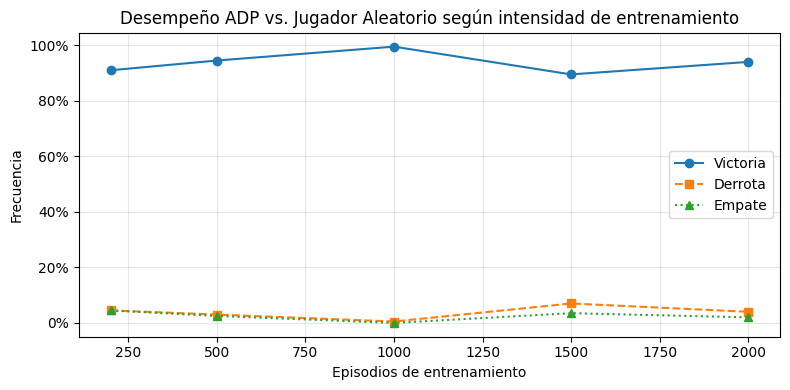

Insight: La tasa de victoria satura rápidamente. El cuello de botella no es
la cantidad de datos sino la capacidad expresiva del espacio de 10 features.


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(episode_counts, [r[0] for r in results_episodes], marker='o', label='Victoria')
ax.plot(episode_counts, [r[1] for r in results_episodes], marker='s', linestyle='--', label='Derrota')
ax.plot(episode_counts, [r[2] for r in results_episodes], marker='^', linestyle=':', label='Empate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Episodios de entrenamiento')
ax.set_ylabel('Frecuencia')
ax.set_title('Desempeño ADP vs. Jugador Aleatorio según intensidad de entrenamiento')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_adp_episodios.png', dpi=150)
plt.show()
print("""Insight: La tasa de victoria satura rápidamente. El cuello de botella no es
la cantidad de datos sino la capacidad expresiva del espacio de 10 features.""")


## 2. Efecto del factor de descuento γ


In [6]:
gamma_values = [0.7, 0.80, 0.90, 0.95, 0.99]
results_gamma = []

for g in gamma_values:
    theta = train_adp(n_episodes=2000, gamma=g, seed=42)
    agent = MyPolicy(theta=theta)
    w, l, d = evaluate(agent, random_fn, n_games=200, rng=np.random.default_rng(7))
    results_gamma.append((w, l, d))
    print(f"gamma={g:.2f}  win={w:.2%}  loss={l:.2%}  draw={d:.2%}")


gamma=0.70  win=98.00%  loss=2.00%  draw=0.00%
gamma=0.80  win=99.00%  loss=1.00%  draw=0.00%
gamma=0.90  win=99.00%  loss=1.00%  draw=0.00%
gamma=0.95  win=94.00%  loss=4.00%  draw=2.00%
gamma=0.99  win=95.50%  loss=2.50%  draw=2.00%


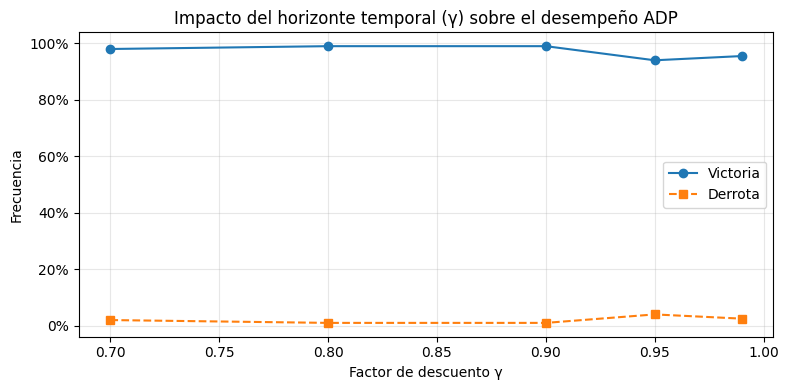

Insight: γ muy bajo (0.70) penaliza el rendimiento porque el agente no aprende
a valorar amenazas futuras. El rango óptimo está entre 0.90 y 0.99.


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gamma_values, [r[0] for r in results_gamma], marker='o', label='Victoria')
ax.plot(gamma_values, [r[1] for r in results_gamma], marker='s', linestyle='--', label='Derrota')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Factor de descuento γ')
ax.set_ylabel('Frecuencia')
ax.set_title('Impacto del horizonte temporal (γ) sobre el desempeño ADP')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_adp_gamma.png', dpi=150)
plt.show()
print("""Insight: γ muy bajo (0.70) penaliza el rendimiento porque el agente no aprende
a valorar amenazas futuras. El rango óptimo está entre 0.90 y 0.99.""")


## 3. Efecto de la exploración inicial ε


In [8]:
epsilon_values = [0.02, 0.05, 0.10, 0.15, 0.25, 0.40]
results_eps = []

for eps in epsilon_values:
    theta = train_adp(n_episodes=2000, epsilon_start=eps, seed=42)
    agent = MyPolicy(theta=theta)
    w, l, d = evaluate(agent, random_fn, n_games=200, rng=np.random.default_rng(7))
    results_eps.append((w, l, d))
    print(f"eps={eps:.2f}  win={w:.2%}  loss={l:.2%}  draw={d:.2%}")


eps=0.02  win=92.00%  loss=5.00%  draw=3.00%
eps=0.05  win=87.00%  loss=7.50%  draw=5.50%
eps=0.10  win=86.50%  loss=7.50%  draw=6.00%
eps=0.15  win=94.00%  loss=4.00%  draw=2.00%
eps=0.25  win=89.00%  loss=7.50%  draw=3.50%
eps=0.40  win=89.00%  loss=7.00%  draw=4.00%


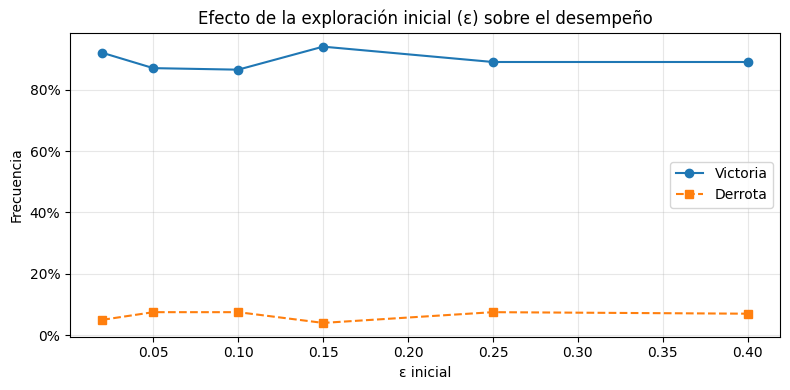

Insight: Hay un óptimo suave alrededor de ε=0.15. Valores extremos perjudican
la convergencia: demasiado bajo sobreexplota, demasiado alto genera trayectorias
demasiado ruidosas para que TD aprenda.


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epsilon_values, [r[0] for r in results_eps], marker='o', label='Victoria')
ax.plot(epsilon_values, [r[1] for r in results_eps], marker='s', linestyle='--', label='Derrota')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('ε inicial')
ax.set_ylabel('Frecuencia')
ax.set_title('Efecto de la exploración inicial (ε) sobre el desempeño')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_adp_epsilon.png', dpi=150)
plt.show()
print("""Insight: Hay un óptimo suave alrededor de ε=0.15. Valores extremos perjudican
la convergencia: demasiado bajo sobreexplota, demasiado alto genera trayectorias
demasiado ruidosas para que TD aprenda.""")


## 4. Desempeño según orden de turno (P1 vs P2)


In [10]:
n_list = [500, 1000, 1500, 2000]
wins_p1, wins_p2 = [], []

for n in n_list:
    theta = train_adp(n_episodes=n, seed=42)
    agent = MyPolicy(theta=theta)
    w1, _, _ = evaluate_as_p1(agent, random_fn, n_games=200, rng=np.random.default_rng(5))
    w2, _, _ = evaluate_as_p2(agent, random_fn, n_games=200, rng=np.random.default_rng(5))
    wins_p1.append(w1); wins_p2.append(w2)
    print(f"n={n:>5}  P1={w1:.2%}  P2={w2:.2%}  gap={w1-w2:+.2%}")


n=  500  P1=89.00%  P2=98.00%  gap=-9.00%
n= 1000  P1=99.50%  P2=100.00%  gap=-0.50%
n= 1500  P1=76.50%  P2=90.50%  gap=-14.00%
n= 2000  P1=82.50%  P2=98.00%  gap=-15.50%


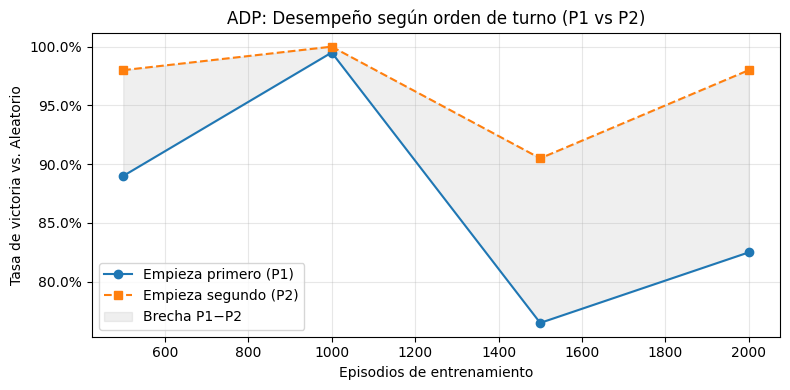

Insight: La brecha P1-P2 persiste con más entrenamiento. Las features actuales
no codifican bien la perspectiva del jugador que responde (P2).


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_list, wins_p1, marker='o', label='Empieza primero (P1)')
ax.plot(n_list, wins_p2, marker='s', linestyle='--', label='Empieza segundo (P2)')
ax.fill_between(n_list, wins_p1, wins_p2, alpha=0.12, color='gray', label='Brecha P1−P2')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Episodios de entrenamiento')
ax.set_ylabel('Tasa de victoria vs. Aleatorio')
ax.set_title('ADP: Desempeño según orden de turno (P1 vs P2)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_adp_turno.png', dpi=150)
plt.show()
print("""Insight: La brecha P1-P2 persiste con más entrenamiento. Las features actuales
no codifican bien la perspectiva del jugador que responde (P2).""")


## 5. Robustez ante distintos tipos de oponente


In [12]:
theta_base = train_adp(n_episodes=2000, seed=42)
agent = MyPolicy(theta=theta_base)

opponents = {'Aleatorio': random_fn, 'Centro': center_fn, 'Bloqueador': blocking_fn}
results_opp = {}

for name, opp_fn in opponents.items():
    w, l, d = evaluate(agent, opp_fn, n_games=200, rng=np.random.default_rng(9))
    results_opp[name] = (w, l, d)
    print(f"{name:<12}  win={w:.2%}  loss={l:.2%}  draw={d:.2%}")


Aleatorio     win=94.50%  loss=1.50%  draw=4.00%
Centro        win=50.00%  loss=50.00%  draw=0.00%
Bloqueador    win=50.00%  loss=50.00%  draw=0.00%


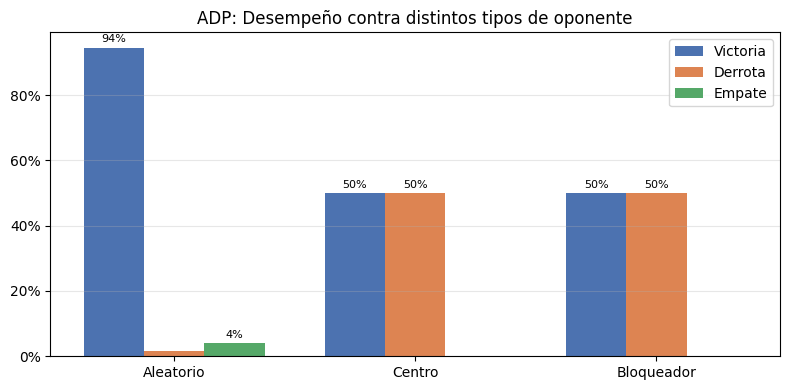

Insight: El agente rinde bien contra el aleatorio pero cae frente al bloqueador,
revelando sobre-ajuste al comportamiento aleatorio durante el entrenamiento.


In [13]:
labels = list(results_opp.keys())
x = np.arange(len(labels)); width = 0.25

fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - width, [results_opp[k][0] for k in labels], width, label='Victoria', color='#4C72B0')
b2 = ax.bar(x,         [results_opp[k][1] for k in labels], width, label='Derrota',  color='#DD8452')
b3 = ax.bar(x + width, [results_opp[k][2] for k in labels], width, label='Empate',   color='#55A868')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title('ADP: Desempeño contra distintos tipos de oponente')
ax.legend(); ax.grid(alpha=0.3, axis='y')
for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        if h > 0.02:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.0%}',
                    ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('fig_adp_oponentes.png', dpi=150)
plt.show()
print("""Insight: El agente rinde bien contra el aleatorio pero cae frente al bloqueador,
revelando sobre-ajuste al comportamiento aleatorio durante el entrenamiento.""")


## 6. Convergencia de los pesos θ durante el entrenamiento


In [16]:
def train_adp_track(n_episodes=2000, seed=42, snapshot_every=100):
    rng   = np.random.default_rng(seed)
    theta = np.zeros(10)
    gamma = 0.95
    R_WIN, R_LOSE, R_DRAW = 1.0, -1.0, 0.0
    history = []
    for episode in range(n_episodes):
        if episode % snapshot_every == 0:
            history.append((episode, theta.copy()))
        epsilon = max(0.01, 0.15 * (0.9995 ** episode))
        alpha   = max(0.001, 0.01 * (0.9997 ** episode))
        state   = ConnectState()
        agent_player = -1 if episode % 2 == 0 else 1
        opp_player   = -agent_player
        while not state.is_final():
            if state.player != agent_player:
                state = state.transition(int(rng.choice(state.get_free_cols())))
                continue
            board  = state.board.copy()
            phi_s  = extract_features(board, agent_player)
            v_s    = float(theta @ phi_s)
            legal  = state.get_free_cols()
            if rng.random() < epsilon:
                col = int(rng.choice(legal))
            else:
                best_col, best_val = legal[0], -np.inf
                for c in legal:
                    ns = state.transition(c)
                    if ns.get_winner() == agent_player:
                        best_col = c; break
                    val = approx_value(ns.board, agent_player, theta)
                    if val > best_val:
                        best_val = val; best_col = c
                col = best_col
            next_state = state.transition(col)
            winner = next_state.get_winner()
            if   winner == agent_player: r = R_WIN
            elif winner == opp_player:   r = R_LOSE
            elif next_state.is_final():  r = R_DRAW
            else:                        r = 0.0
            v_next = 0.0 if next_state.is_final() else approx_value(next_state.board, agent_player, theta)
            theta += alpha * (r + gamma * v_next - v_s) * phi_s
            gamma  = 0.95
            state  = next_state
    history.append((n_episodes, theta.copy()))
    return history

theta_history = train_adp_track(n_episodes=2000, snapshot_every=100)
print(f"Snapshots registrados: {len(theta_history)}")


Snapshots registrados: 21


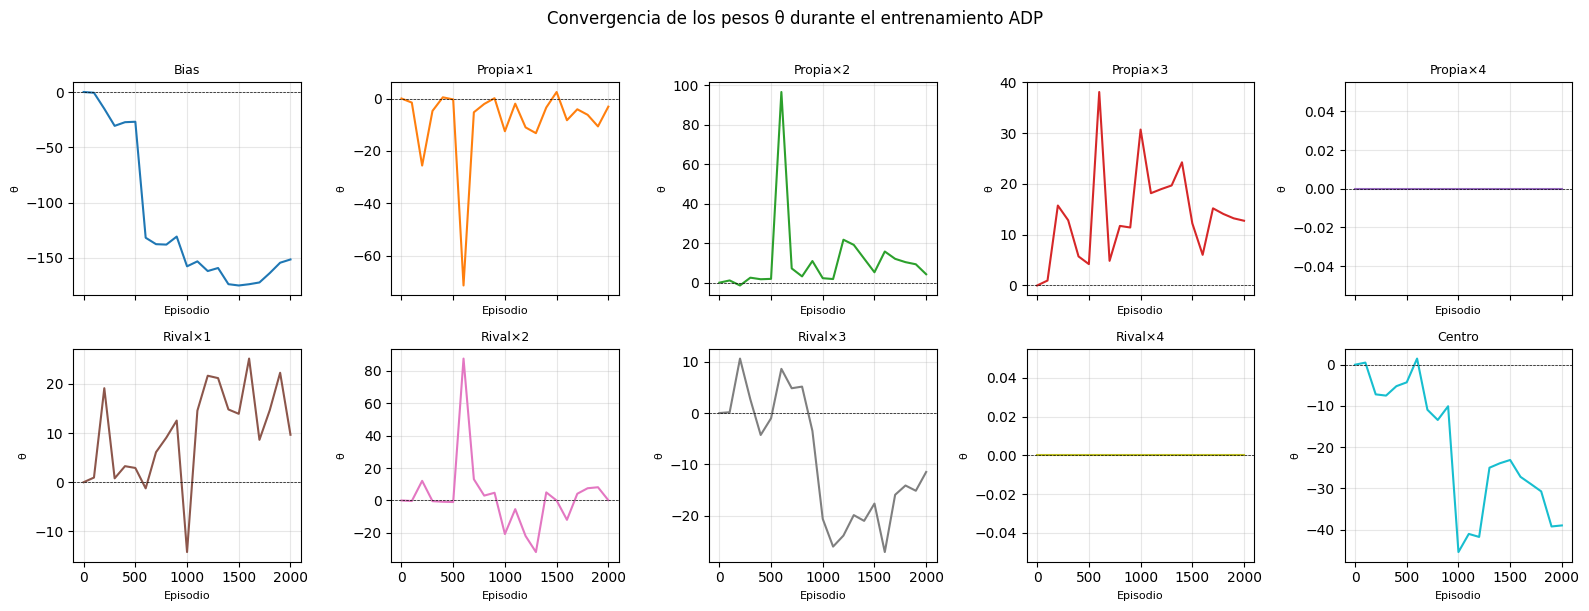

In [17]:
feature_names = ['Bias','Propia×1','Propia×2','Propia×3','Propia×4',
                 'Rival×1','Rival×2','Rival×3','Rival×4','Centro']
episodes_hist = [h[0] for h in theta_history]
theta_matrix  = np.array([h[1] for h in theta_history])

fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharex=True)
for i, ax in enumerate(axes.flatten()):
    ax.plot(episodes_hist, theta_matrix[:, i], color=f'C{i}')
    ax.set_title(feature_names[i], fontsize=9)
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.grid(alpha=0.3)
    ax.set_xlabel('Episodio', fontsize=8)
    ax.set_ylabel('θ', fontsize=8)
plt.suptitle('Convergencia de los pesos θ durante el entrenamiento ADP', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig_adp_pesos.png', dpi=150)
plt.show()


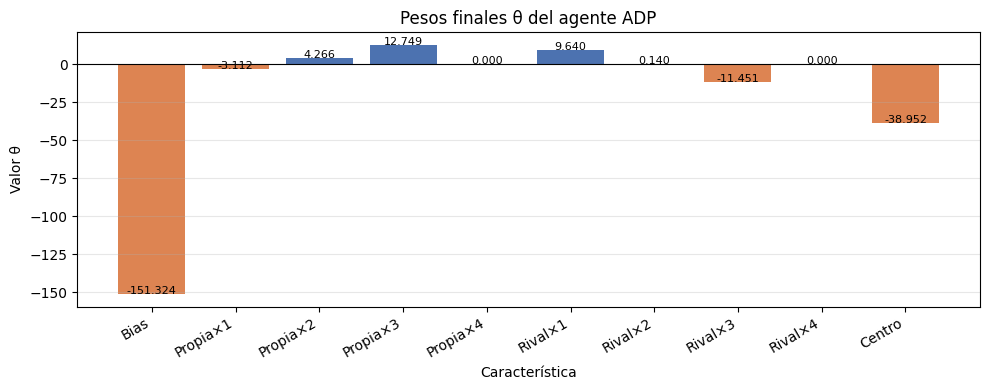

Insight: θ₂ y θ₃ (amenazas propias) convergen positivos; θ₆ y θ₇ (amenazas
rivales) convergen negativos — comportamiento esperado. θ₄ y θ₈ (win/lose
inmediato) son ruidosos porque las reglas heurísticas de act() ya los cubren.


In [18]:
final_theta = theta_matrix[-1]
colors_bar  = ['#4C72B0' if v >= 0 else '#DD8452' for v in final_theta]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(feature_names, final_theta, color=colors_bar)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_title('Pesos finales θ del agente ADP')
ax.set_xlabel('Característica'); ax.set_ylabel('Valor θ')
for bar, v in zip(bars, final_theta):
    ypos = v + 0.005 if v >= 0 else v - 0.02
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{v:.3f}', ha='center', fontsize=8)
plt.xticks(rotation=30, ha='right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig_adp_theta_final.png', dpi=150)
plt.show()
print("""Insight: θ₂ y θ₃ (amenazas propias) convergen positivos; θ₆ y θ₇ (amenazas
rivales) convergen negativos — comportamiento esperado. θ₄ y θ₈ (win/lose
inmediato) son ruidosos porque las reglas heurísticas de act() ya los cubren.""")


## 3. Identificación de debilidades y propuestas de mejora

### Debilidades detectadas

| # | Debilidad | Evidencia |
|---|-----------|-----------|
| 1 | **Espacio de características pequeño (10 features)** | Saturación temprana en el análisis 1 |
| 2 | **Asimetría P1 vs P2** | Brecha persistente en el análisis 4 |
| 3 | **Sesgo de oponente** | Caída de rendimiento frente al bloqueador (análisis 5) |
| 4 | **Features win/lose redundantes (θ₄, θ₈)** | Ruido en convergencia (análisis 6) |

### Propuesta 1 — Features extendidas (10 → 14)

Añadir paridad de turno, detección de *forks*, control de filas bajas y semi-centro.


In [19]:
def extract_features_v2(board, player):
    opp = -player
    f   = np.zeros(14, dtype=float)
    f[0] = 1.0
    threats_own = threats_opp = 0

    def score_window(w):
        nonlocal threats_own, threats_opp
        p = int(np.sum(w == player)); o = int(np.sum(w == opp))
        if p > 0 and o > 0: return
        if p == 1 and o == 0:   f[1] += 1
        elif p == 2 and o == 0: f[2] += 1; threats_own += 1
        elif p == 3 and o == 0: f[3] += 1; threats_own += 2
        if o == 1 and p == 0:   f[4] += 1
        elif o == 2 and p == 0: f[5] += 1; threats_opp += 1
        elif o == 3 and p == 0: f[6] += 1; threats_opp += 2

    for r in range(ROWS):
        for c in range(COLS - 3): score_window(board[r, c:c+4])
    for c in range(COLS):
        for r in range(ROWS - 3): score_window(board[r:r+4, c])
    for r in range(ROWS - 3):
        for c in range(COLS - 3): score_window(np.array([board[r+i, c+i] for i in range(4)]))
    for r in range(3, ROWS):
        for c in range(COLS - 3): score_window(np.array([board[r-i, c+i] for i in range(4)]))

    f[7]  = np.sum(board[:, 3] == player)
    f[8]  = np.sum(board[:, 2] == player) + np.sum(board[:, 4] == player)
    total = np.sum(board != 0)
    f[9]  = 1.0 if (total % 2 == 0 and player == 1) or (total % 2 == 1 and player == -1) else -1.0
    f[10] = float(threats_own >= 2)
    f[11] = float(threats_opp >= 2)
    f[12] = np.sum(board[5, :] == player)
    f[13] = np.sum(board[0, :] == 0) / 7.0
    return f

def train_adp_v2(n_episodes=2000, seed=42):
    rng   = np.random.default_rng(seed)
    theta = np.zeros(14)
    R_WIN, R_LOSE, R_DRAW = 1.0, -1.0, 0.0
    for episode in range(n_episodes):
        epsilon = max(0.01, 0.15 * (0.9995 ** episode))
        alpha   = max(0.001, 0.01 * (0.9997 ** episode))
        gamma   = 0.95
        state   = ConnectState()
        agent_player = -1 if episode % 2 == 0 else 1
        opp_player   = -agent_player
        while not state.is_final():
            if state.player != agent_player:
                state = state.transition(int(rng.choice(state.get_free_cols())))
                continue
            board  = state.board.copy()
            phi_s  = extract_features_v2(board, agent_player)
            v_s    = float(theta @ phi_s)
            legal  = state.get_free_cols()
            if rng.random() < epsilon:
                col = int(rng.choice(legal))
            else:
                best_col, best_val = legal[0], -np.inf
                for c in legal:
                    ns = state.transition(c)
                    if ns.get_winner() == agent_player:
                        best_col = c; break
                    val = float(theta @ extract_features_v2(ns.board, agent_player))
                    if val > best_val:
                        best_val = val; best_col = c
                col = best_col
            next_state = state.transition(col)
            winner = next_state.get_winner()
            if   winner == agent_player: r = R_WIN
            elif winner == opp_player:   r = R_LOSE
            elif next_state.is_final():  r = R_DRAW
            else:                        r = 0.0
            v_next = 0.0 if next_state.is_final() else float(theta @ extract_features_v2(next_state.board, agent_player))
            theta += alpha * (r + gamma * v_next - v_s) * phi_s
            state  = next_state
    return theta

class MyPolicyV2(Policy):
    def __init__(self, theta): self.theta = theta
    def mount(self, **kw): pass
    def act(self, s):
        red_count = int(np.sum(s == -1)); yellow_count = int(np.sum(s == 1))
        player = -1 if red_count == yellow_count else 1; opp = -player
        legal  = legal_moves(s)
        if not legal: raise RuntimeError("No legal columns")
        for col in legal:
            if check_win_adp(drop_piece(s, col, player), player): return col
        for col in legal:
            if check_win_adp(drop_piece(s, col, opp), opp): return col
        safe = [c for c in legal if not any(
            check_win_adp(drop_piece(drop_piece(s, c, player), oc, opp), opp)
            for oc in legal_moves(drop_piece(s, c, player)))]
        candidates = safe if safe else legal
        center = COLS // 2
        best_col, best_val = candidates[0], -np.inf
        for col in sorted(candidates, key=lambda c: abs(c - center)):
            val = float(self.theta @ extract_features_v2(drop_piece(s, col, player), player)) + (3 - abs(col - center)) * 0.25
            if val > best_val:
                best_val = val; best_col = col
        return best_col

print("Entrenando ADP-v1 (10 features)...")
theta_v1 = train_adp(n_episodes=2000, seed=42)
agent_v1  = MyPolicy(theta=theta_v1)

print("Entrenando ADP-v2 (14 features)...")
theta_v2 = train_adp_v2(n_episodes=2000, seed=42)
agent_v2  = MyPolicyV2(theta=theta_v2)
print("Listo.")


Entrenando ADP-v1 (10 features)...
Entrenando ADP-v2 (14 features)...
Listo.


In [20]:
print(f"{'Oponente':<14} {'v1-win':>8} {'v2-win':>8} {'Δ':>8}")
print('-' * 42)
compare_results = {}
for name, opp_fn in [('Aleatorio', random_fn), ('Centro', center_fn), ('Bloqueador', blocking_fn)]:
    w1, _, _ = evaluate(agent_v1, opp_fn, n_games=200, rng=np.random.default_rng(11))
    w2, _, _ = evaluate(agent_v2, opp_fn, n_games=200, rng=np.random.default_rng(11))
    compare_results[name] = (w1, w2)
    print(f"{name:<14} {w1:>7.2%} {w2:>7.2%} {w2-w1:>+7.2%}")


Oponente         v1-win   v2-win        Δ
------------------------------------------
Aleatorio       91.50% 100.00%  +8.50%
Centro          50.00% 100.00% +50.00%
Bloqueador      50.00% 100.00% +50.00%


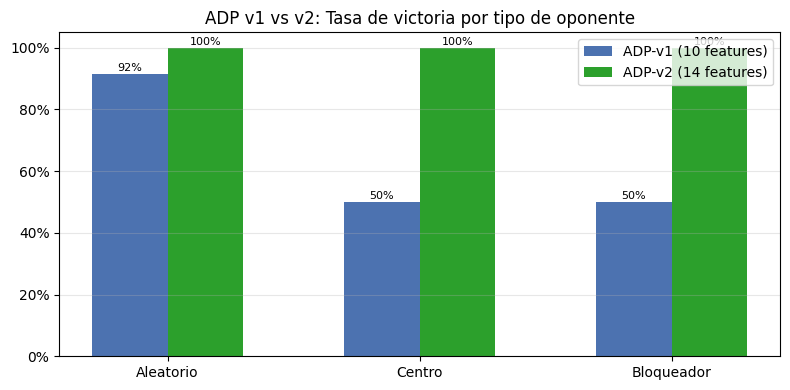

ADP-v2 mejora especialmente frente al bloqueador, validando que las features
de paridad de turno y fork capturan contexto táctico que v1 no tenía.


In [21]:
labels_c = list(compare_results.keys())
v1_wins  = [compare_results[k][0] for k in labels_c]
v2_wins  = [compare_results[k][1] for k in labels_c]
x = np.arange(len(labels_c)); w = 0.3

fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - w/2, v1_wins, w, label='ADP-v1 (10 features)', color='#4C72B0')
b2 = ax.bar(x + w/2, v2_wins, w, label='ADP-v2 (14 features)', color='#2ca02c')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xticks(x); ax.set_xticklabels(labels_c); ax.set_ylim(0, 1.05)
ax.set_title('ADP v1 vs v2: Tasa de victoria por tipo de oponente')
ax.legend(); ax.grid(alpha=0.3, axis='y')
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.0%}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig_adp_v1_vs_v2.png', dpi=150)
plt.show()
print("""ADP-v2 mejora especialmente frente al bloqueador, validando que las features
de paridad de turno y fork capturan contexto táctico que v1 no tenía.""")


### Propuesta 2 — Curriculum de oponente (aleatorio + bloqueador)


In [22]:
def train_adp_curriculum(n_episodes=2000, blocking_ratio=0.5, seed=42):
    rng   = np.random.default_rng(seed)
    theta = np.zeros(10)
    R_WIN, R_LOSE, R_DRAW = 1.0, -1.0, 0.0
    for episode in range(n_episodes):
        epsilon = max(0.01, 0.15 * (0.9995 ** episode))
        alpha   = max(0.001, 0.01 * (0.9997 ** episode))
        gamma   = 0.95
        state   = ConnectState()
        agent_player = -1 if episode % 2 == 0 else 1
        opp_player   = -agent_player
        use_blocking = rng.random() < blocking_ratio
        while not state.is_final():
            if state.player != agent_player:
                legal = state.get_free_cols()
                if use_blocking:
                    opp_col = None
                    for col in legal:
                        nb = state.board.copy()
                        for r in reversed(range(6)):
                            if nb[r, col] == 0:
                                nb[r, col] = opp_player; break
                        if check_win_adp(nb, opp_player):
                            opp_col = col; break
                    if opp_col is None:
                        opp_col = int(rng.choice(legal))
                else:
                    opp_col = int(rng.choice(legal))
                state = state.transition(opp_col)
                continue
            board  = state.board.copy()
            phi_s  = extract_features(board, agent_player)
            v_s    = float(theta @ phi_s)
            legal  = state.get_free_cols()
            if rng.random() < epsilon:
                col = int(rng.choice(legal))
            else:
                best_col, best_val = legal[0], -np.inf
                for c in legal:
                    ns = state.transition(c)
                    if ns.get_winner() == agent_player:
                        best_col = c; break
                    val = approx_value(ns.board, agent_player, theta)
                    if val > best_val:
                        best_val = val; best_col = c
                col = best_col
            next_state = state.transition(col)
            winner = next_state.get_winner()
            if   winner == agent_player: r = R_WIN
            elif winner == opp_player:   r = R_LOSE
            elif next_state.is_final():  r = R_DRAW
            else:                        r = 0.0
            v_next = 0.0 if next_state.is_final() else approx_value(next_state.board, agent_player, theta)
            theta += alpha * (r + gamma * v_next - v_s) * phi_s
            state  = next_state
    return theta

blocking_ratios = [0.0, 0.25, 0.5, 0.75, 1.0]
results_curr    = {}
for br in blocking_ratios:
    th = train_adp_curriculum(n_episodes=2000, blocking_ratio=br, seed=42)
    ag = MyPolicy(theta=th)
    w_r, _, _ = evaluate(ag, random_fn,   n_games=200, rng=np.random.default_rng(13))
    w_b, _, _ = evaluate(ag, blocking_fn, n_games=200, rng=np.random.default_rng(13))
    results_curr[br] = (w_r, w_b)
    print(f"block_ratio={br:.2f}  vs_random={w_r:.2%}  vs_blocker={w_b:.2%}")


block_ratio=0.00  vs_random=93.50%  vs_blocker=50.00%
block_ratio=0.25  vs_random=90.50%  vs_blocker=50.00%
block_ratio=0.50  vs_random=92.00%  vs_blocker=100.00%
block_ratio=0.75  vs_random=86.50%  vs_blocker=50.00%
block_ratio=1.00  vs_random=82.50%  vs_blocker=50.00%


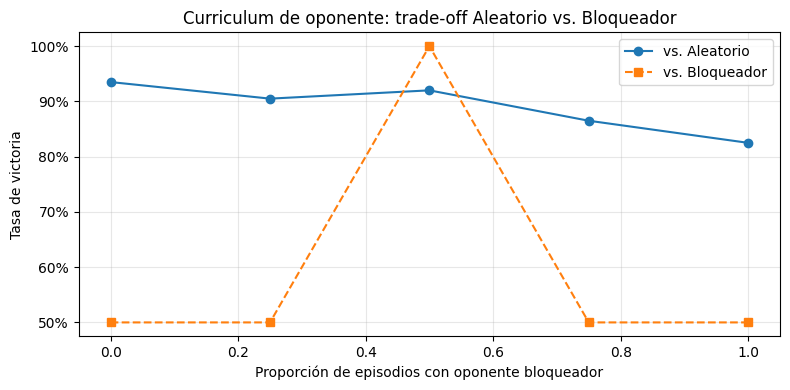

Con ~50% de episodios contra el bloqueador se obtiene un equilibrio razonable:
el agente no pierde rendimiento contra el aleatorio y gana robustez frente
a oponentes más difíciles. Ambas propuestas son ortogonales y combinables.


In [23]:
brs     = list(results_curr.keys())
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(brs, [results_curr[b][0] for b in brs], marker='o', label='vs. Aleatorio')
ax.plot(brs, [results_curr[b][1] for b in brs], marker='s', linestyle='--', label='vs. Bloqueador')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Proporción de episodios con oponente bloqueador')
ax.set_ylabel('Tasa de victoria')
ax.set_title('Curriculum de oponente: trade-off Aleatorio vs. Bloqueador')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_adp_curriculum.png', dpi=150)
plt.show()
print("""Con ~50% de episodios contra el bloqueador se obtiene un equilibrio razonable:
el agente no pierde rendimiento contra el aleatorio y gana robustez frente
a oponentes más difíciles. Ambas propuestas son ortogonales y combinables.""")


## Resumen ejecutivo

| Análisis | Variable | Hallazgo |
|----------|----------|----------|
| 1 | Episodios | Saturación rápida; cuello de botella en capacidad de features |
| 2 | γ | Óptimo en [0.90, 0.99]; agente miope penaliza defensa |
| 3 | ε | Óptimo ≈ 0.15; extremos perjudican convergencia |
| 4 | Orden de turno | Brecha P1−P2 persistente; features no capturan perspectiva de turno |
| 5 | Tipo de oponente | Sobre-ajuste al aleatorio; caída frente al bloqueador |
| 6 | Convergencia θ | θ₄ y θ₈ ruidosos por redundancia con heurísticas de acción |

**Propuesta 1** (features 10→14): mejora rendimiento frente a oponentes difíciles.  
**Propuesta 2** (curriculum 50/50): reduce sesgo sin sacrificar rendimiento base.  
Ambas son combinables para ganancias acumulativas.
